# Microproyecto 1 — Paleta de colores con Machine Learning No Supervisado

**Objetivo:** desarrollar un método basado en técnicas de agrupación (clustering) que extraiga los tonos dominantes de una imagen y genere un muestrario de colores representativo, evaluado sobre obras de arte del dataset [WikiArt](https://www.kaggle.com/datasets/steubk/wikiart).

Este notebook sigue las actividades pedidas en el enunciado del curso (ver `../README.md` y `../PLAN.md` para el detalle completo):

1. Selección de un conjunto diverso de imágenes (6–10, distintos estilos artísticos).
2. Preparación de las imágenes (pipeline de transformaciones).
3. Modelo de agrupación para identificar colores dominantes (número de clusters variable por imagen).
4. Generación del muestrario de colores + visualización 2D (t-SNE) de la distribución de colores.

La primera celda de código es solo una prueba de conectividad con `kagglehub` (descarga una imagen de ejemplo para confirmar que el mecanismo de descarga funciona); no forma parte de la selección final de imágenes.

In [1]:
import kagglehub
import pandas as pd
from kagglehub import KaggleDatasetAdapter
from pathlib import Path
# Descarga la última versión del dataset (ejemplo: Titanic)
DATASET = "steubk/wikiart"
path=kagglehub.dataset_download(DATASET, path='Abstract_Expressionism/aaron-siskind_acolman-1-1955.jpg')

path

'C:\\Users\\juanp\\.cache\\kagglehub\\datasets\\steubk\\wikiart\\versions\\1\\Abstract_Expressionism/aaron-siskind_acolman-1-1955.jpg'

In [2]:
df = pd.read_csv("../data/classes.csv")
print(df[["filename", "genre"]].head())

                                            filename  \
0  Abstract_Expressionism/aaron-siskind_acolman-1...   
1  Abstract_Expressionism/aaron-siskind_chicago-6...   
2  Abstract_Expressionism/aaron-siskind_glouceste...   
3  Abstract_Expressionism/aaron-siskind_jerome-ar...   
4  Abstract_Expressionism/aaron-siskind_kentucky-...   

                        genre  
0  ['Abstract Expressionism']  
1  ['Abstract Expressionism']  
2  ['Abstract Expressionism']  
3  ['Abstract Expressionism']  
4  ['Abstract Expressionism']  


## Selección del conjunto de imágenes

Con los metadatos de `classes.csv` cargados, seleccionamos un subconjunto diverso de imágenes para trabajar durante todo el notebook (preparación, clustering y generación de paleta).

**Criterio de selección:**

- Se eligieron 5 estilos artísticos con paletas de color e identidad visual claramente distintas entre sí, para poner a prueba el método de agrupación sobre casos variados:
  - **Baroque**: tonos oscuros y dramáticos (claroscuro), predominancia de marrones y dorados.
  - **Impressionism**: paleta luminosa y difusa, colores pastel y pinceladas de luz.
  - **Cubism**: paleta geométrica y apagada, tonos tierra y grises.
  - **Ukiyo e**: colores planos y muy saturados, tradición del grabado japonés.
  - **Action painting**: composiciones abstractas con contrastes fuertes (blancos, negros y colores primarios).
- Se excluyó **Romanticism** del conjunto original de 6 estilos porque comparte una paleta cálida y dramática similar a la de Baroque; priorizamos maximizar la diversidad cromática entre estilos dado el límite de imágenes.
- Se toman **2 imágenes por estilo** (5 estilos × 2 = 10 imágenes), dentro del rango de 6–10 imágenes pedido, y por encima del mínimo de 3 estilos/pintores distintos requerido por la rúbrica.
- Se usa `random_state=42` para que la selección sea reproducible.

In [3]:
styles = [
    "Impressionism",
    "Cubism",
    "Baroque",
    "Ukiyo e",
    "Action painting",
]

import ast

df["style"] = df["genre"].apply(
    lambda x: ast.literal_eval(x)[0]
)

In [4]:
N_PER_STYLE = 2  # 5 estilos x 2 imagenes = 10 imagenes (rango 6-10 pedido por la rubrica)

selected = (
    df[df["style"].isin(styles)]
    .groupby("style", group_keys=False)
    .sample(n=N_PER_STYLE, random_state=42)
)
print(selected[["filename", "artist", "style"]])

                                                filename  \
2122   Action_painting/jackson-pollock_eyes-in-the-he...   
2104   Action_painting/franz-kline_torches-mauve-1960...   
8328   Baroque/rembrandt_angel-departing-from-the-fam...   
7297   Baroque/hendrick-terbrugghen_a-laughing-bravo-...   
66794   Cubism/jack-bush_ferry-at-bigwin-island-1952.jpg   
10946  Cubism/fernand-leger_the-creation-of-the-world...   
21756  Impressionism/camille-pissarro_pink-peonies-18...   
23086        Impressionism/claude-monet_springtime-1.jpg   
79768                  Ukiyo_e/hiroshige_cherry-tree.jpg   
63287  Ukiyo_e/katsushika-hokusai_peasants-in-autumn.jpg   

                     artist            style  
2122        jackson pollock  Action painting  
2104            franz kline  Action painting  
8328              rembrandt          Baroque  
7297   hendrick terbrugghen          Baroque  
66794             jack bush           Cubism  
10946         fernand leger           Cubism  
21756     

Con la selección definida, descargamos localmente (vía `kagglehub`) las 10 imágenes elegidas para poder procesarlas en los siguientes pasos.

In [5]:
for filename in selected["filename"]:

    path = kagglehub.dataset_download(
        DATASET,
        path=filename
    )

    print(path)

C:\Users\juanp\.cache\kagglehub\datasets\steubk\wikiart\versions\1\Action_painting/jackson-pollock_eyes-in-the-heat-1946(2).jpg


C:\Users\juanp\.cache\kagglehub\datasets\steubk\wikiart\versions\1\Action_painting/franz-kline_torches-mauve-1960.jpg


C:\Users\juanp\.cache\kagglehub\datasets\steubk\wikiart\versions\1\Baroque/rembrandt_angel-departing-from-the-family-of-tobias-1641.jpg


C:\Users\juanp\.cache\kagglehub\datasets\steubk\wikiart\versions\1\Baroque/hendrick-terbrugghen_a-laughing-bravo-with-a-bass-viol-and-a-glass.jpg


C:\Users\juanp\.cache\kagglehub\datasets\steubk\wikiart\versions\1\Cubism/jack-bush_ferry-at-bigwin-island-1952.jpg


C:\Users\juanp\.cache\kagglehub\datasets\steubk\wikiart\versions\1\Cubism/fernand-leger_the-creation-of-the-world.jpg


C:\Users\juanp\.cache\kagglehub\datasets\steubk\wikiart\versions\1\Impressionism/camille-pissarro_pink-peonies-1873.jpg


C:\Users\juanp\.cache\kagglehub\datasets\steubk\wikiart\versions\1\Impressionism/claude-monet_springtime-1.jpg


C:\Users\juanp\.cache\kagglehub\datasets\steubk\wikiart\versions\1\Ukiyo_e/hiroshige_cherry-tree.jpg


C:\Users\juanp\.cache\kagglehub\datasets\steubk\wikiart\versions\1\Ukiyo_e/katsushika-hokusai_peasants-in-autumn.jpg


In [6]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth
from PIL import Image


Estas librerías se usan a partir de aquí: `OpenCV`/`PIL` para la preparación de imágenes de esta sección (actividades b y c), y `KMeans`/`MeanShift` de `scikit-learn` como candidatos para el modelo de agrupación de la actividad (d), todavía pendiente.

In [7]:
print(selected["style"].unique())

['Action painting' 'Baroque' 'Cubism' 'Impressionism' 'Ukiyo e']


## Imágenes seleccionadas

A continuación se muestran las 10 imágenes seleccionadas, agrupadas por estilo, confirmando visualmente la diversidad buscada en la selección.

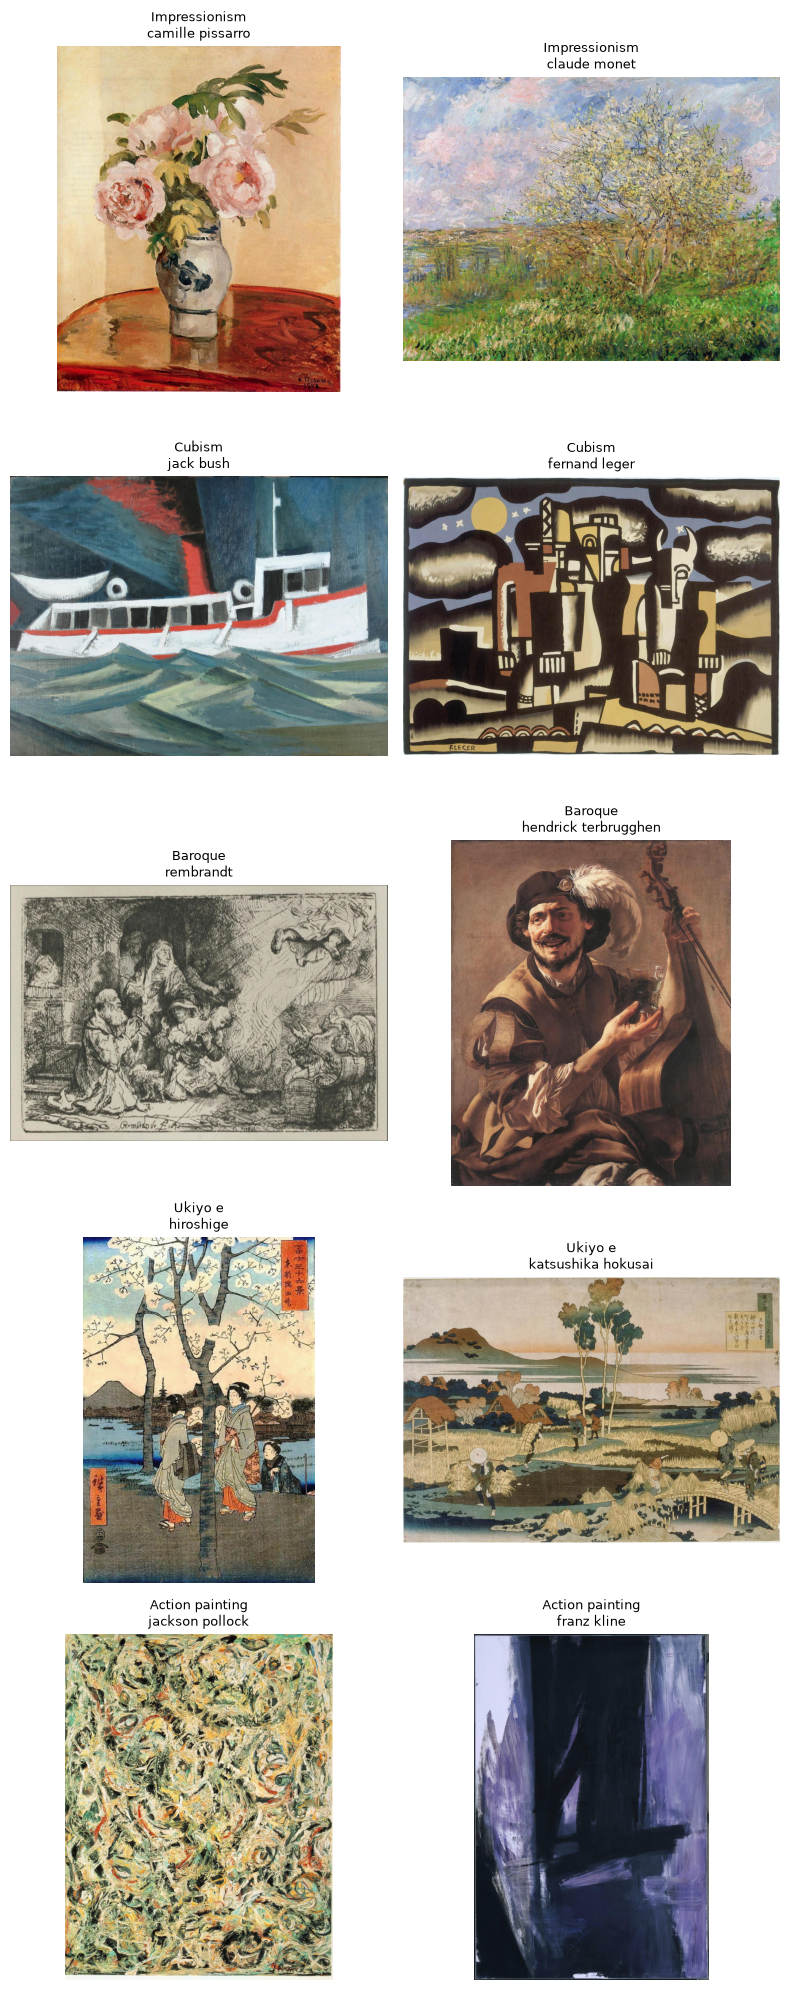

In [8]:
n_styles = len(styles)

fig, axes = plt.subplots(n_styles, N_PER_STYLE, figsize=(4 * N_PER_STYLE, 4 * n_styles))

for row, style in enumerate(styles):
    imagenes = selected[selected["style"] == style]
    for col, (_, img_row) in enumerate(imagenes.iterrows()):
        ax = axes[row, col]

        path = kagglehub.dataset_download(
            DATASET,
            path=img_row["filename"]
        )

        img = Image.open(path)

        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f'{style}\n{img_row["artist"]}', fontsize=9)

plt.tight_layout()
plt.show()

## Preparación de las imágenes (actividades b y c)

Antes de agrupar colores hay que transformar cada imagen a una representación adecuada para el clustering. El pipeline tiene cuatro pasos, cada uno con su justificación:

**1. Carga y orden de canales (BGR -> RGB).** `OpenCV` lee las imágenes en orden BGR. Se convierten a RGB para que las visualizaciones (`matplotlib`) muestren los colores reales y para partir de una convención estándar antes de pasar a Lab.

**2. Redimensionado: lado mayor a `max_dim=150` px, interpolación por área.** Una obra de WikiArt puede tener millones de píxeles, pero el clustering de color no necesita resolución espacial: solo la *distribución* de colores, que se conserva al submuestrear la imagen. Reducir a 150 px baja el número de muestras de ~10^6 a ~10^4 y hace que la búsqueda de `k` por imagen (actividad d, varias corridas de K-Means por imagen) sea viable en tiempo. Se usa `cv2.INTER_AREA`, que promedia los píxeles de cada región al reducir: no inventa colores nuevos (a diferencia de interpolaciones bicúbicas), así que la paleta resultante no se contamina. Solo se reduce (nunca se amplía): si la imagen ya es menor a 150 px se deja igual.

**3. Conversión a espacio de color CIELAB.** K-Means y MeanShift agrupan minimizando distancia euclidiana. En RGB la distancia euclidiana no se corresponde con la diferencia de color que percibe el ojo (dos pares de colores a la misma distancia RGB pueden verse muy distintos o casi iguales). CIELAB está diseñado para ser aproximadamente *perceptualmente uniforme*: distancia euclidiana en Lab ~ diferencia percibida. Agrupar en Lab produce clusters que se corresponden con "colores que una persona agruparía". `L` es luminosidad, `a` el eje verde-rojo y `b` el azul-amarillo. (En Lab de 8 bits de OpenCV los tres canales quedan en el rango 0–255, con 128 como neutro en `a` y `b`.)

**4. Aplanado a matriz `(n_píxeles, 3)`.** Cada píxel se trata como una muestra independiente de 3 dimensiones `(L, a, b)`. Se descarta la posición `(x, y)`: el objetivo es agrupar colores, no regiones de la imagen.

**Decisión: no se estandariza ni normaliza.** Los tres canales de Lab ya comparten rango (0–255) y tienen significado perceptual homogéneo, así que ninguno domina artificialmente la distancia. Aplicar z-score por canal deformaría precisamente las distancias perceptuales que motivaron elegir Lab, y escalar a [0,1] no aportaría nada porque el rango ya es común. Por eso se pasan los píxeles Lab tal cual al modelo.

La actividad (c) consiste en dejar estos pasos encapsulados en una función reutilizable, aplicable a cualquier imagen del dataset y no solo a las 10 seleccionadas.

In [9]:
def preparar_imagen(path, max_dim=150):
    """Pipeline de preparacion de una imagen para el clustering de color.

    Pasos: carga con OpenCV -> BGR a RGB -> resize (lado mayor = max_dim,
    interpolacion por area) -> RGB a CIELAB -> aplanado a (n_pixeles, 3).

    Parametros
    ----------
    path : str o Path
        Ruta a la imagen en disco.
    max_dim : int
        Tamano al que se reduce el lado mayor. Si la imagen ya es mas
        pequena, se deja sin cambios.

    Devuelve
    --------
    img_rgb : ndarray (h, w, 3) uint8
        Imagen redimensionada en RGB, para visualizacion.
    pixeles_lab : ndarray (n_pixeles, 3) float32
        Pixeles en CIELAB, listos para pasar al modelo de clustering.
    """
    img_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    h, w = img_rgb.shape[:2]
    escala = max_dim / max(h, w)
    if escala < 1:
        nuevo_tam = (max(1, round(w * escala)), max(1, round(h * escala)))
        img_rgb = cv2.resize(img_rgb, nuevo_tam, interpolation=cv2.INTER_AREA)

    img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB).astype("float32")
    pixeles_lab = img_lab.reshape(-1, 3)

    return img_rgb, pixeles_lab


Aplicamos `preparar_imagen` a las 10 imágenes seleccionadas y guardamos los resultados en el diccionario `imagenes_preparadas` (indexado por `filename`), que se reutiliza en las etapas de clustering y de generación de paleta. La tabla de salida es evidencia de la reducción de píxeles que consigue el pipeline.

In [10]:
imagenes_preparadas = {}

for _, fila in selected.iterrows():
    ruta = kagglehub.dataset_download(DATASET, path=fila["filename"])
    img_rgb, pixeles_lab = preparar_imagen(ruta)
    imagenes_preparadas[fila["filename"]] = {
        "style": fila["style"],
        "artist": fila["artist"],
        "img_rgb": img_rgb,
        "pixeles_lab": pixeles_lab,
    }

# Evidencia: reduccion de pixeles por imagen (resolucion original -> resolucion tras el resize)
print(f'{"estilo":<16} {"original":>13} {"preparada":>11} {"pixeles":>9}   archivo')
for filename, datos in imagenes_preparadas.items():
    orig = cv2.imread(str(kagglehub.dataset_download(DATASET, path=filename)))
    ho, wo = orig.shape[:2]
    hp, wp = datos["img_rgb"].shape[:2]
    n_pix = datos["pixeles_lab"].shape[0]
    print(f'{datos["style"]:<16} {f"{ho}x{wo}":>13} {f"{hp}x{wp}":>11} {n_pix:>9}   {filename.split("/")[-1]}')


estilo                original   preparada   pixeles   archivo


Action painting      1782x1382     150x116     17400   jackson-pollock_eyes-in-the-heat-1946(2).jpg


Action painting      2037x1382     150x102     15300   franz-kline_torches-mauve-1960.jpg


Baroque              1382x2035     102x150     15300   rembrandt_angel-departing-from-the-family-of-tobias-1641.jpg


Baroque              1705x1382     150x122     18300   hendrick-terbrugghen_a-laughing-bravo-with-a-bass-viol-and-a-glass.jpg


...

Cubism               1382x1873     111x150     16650   fernand-leger_the-creation-of-the-world.jpg


Impressionism        1685x1382     150x123     18450   camille-pissarro_pink-peonies-1873.jpg


Impressionism        1382x1834     113x150     16950   claude-monet_springtime-1.jpg


Ukiyo e              2065x1382     150x100     15000   hiroshige_cherry-tree.jpg


Ukiyo e              1382x1961     106x150     15900   katsushika-hokusai_peasants-in-autumn.jpg


### Verificación: el redimensionado conserva la distribución de color

El paso más agresivo del pipeline es la reducción a 150 px. Para justificar que no distorsiona la paleta, comparamos una imagen antes y después del resize en dos planos:

- **Visual**: original vs. redimensionada lado a lado; la composición de colores se ve igual.
- **Cuantitativo**: color RGB promedio y desviación estándar por canal. Se espera que **la media por canal se conserve** (misma tendencia central de cada color) y que la **desviación estándar baje algo**: `cv2.INTER_AREA` promedia píxeles vecinos, así que atenúa la textura fina y el "ruido" de pincelada. Para el clustering de color esto no es un problema —incluso ayuda—: los colores dominantes (los centros de los clusters) dependen de dónde se concentra la masa de píxeles, no de la varianza local, así que no se desplazan.

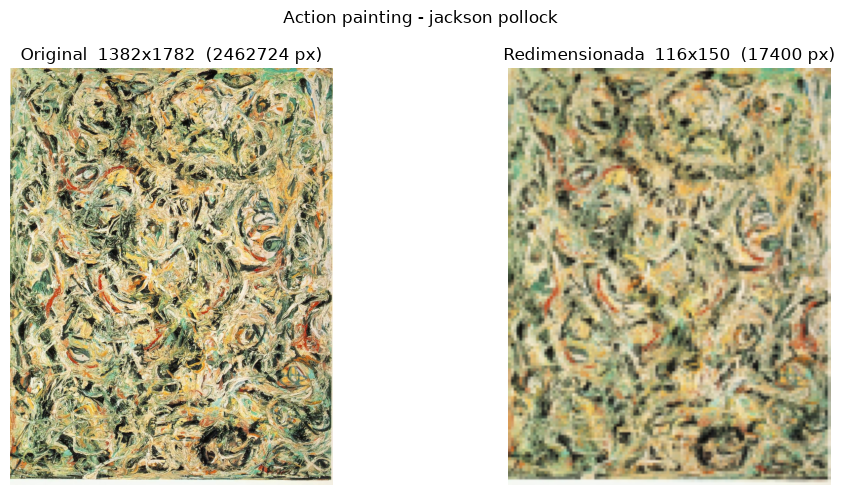

                            R                  G                  B   (media +/- desv. est.)
original    168.0 +/-  66.2  159.7 +/-  61.5  119.5 +/-  56.8
reducida    168.0 +/-  48.8  159.7 +/-  43.2  119.5 +/-  38.1


In [11]:
ejemplo = selected.iloc[0]
ruta_ejemplo = kagglehub.dataset_download(DATASET, path=ejemplo["filename"])

orig_rgb = cv2.cvtColor(cv2.imread(str(ruta_ejemplo), cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
red_rgb = imagenes_preparadas[ejemplo["filename"]]["img_rgb"]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(orig_rgb)
axes[0].set_title(f'Original  {orig_rgb.shape[1]}x{orig_rgb.shape[0]}  ({orig_rgb.shape[0] * orig_rgb.shape[1]} px)')
axes[0].axis("off")
axes[1].imshow(red_rgb)
axes[1].set_title(f'Redimensionada  {red_rgb.shape[1]}x{red_rgb.shape[0]}  ({red_rgb.shape[0] * red_rgb.shape[1]} px)')
axes[1].axis("off")
fig.suptitle(f'{ejemplo["style"]} - {ejemplo["artist"]}')
plt.tight_layout()
plt.show()

orig_flat = orig_rgb.reshape(-1, 3)
red_flat = red_rgb.reshape(-1, 3)
print(f'{"":<10} {"R":>18} {"G":>18} {"B":>18}   (media +/- desv. est.)')
for etiqueta, datos in [("original", orig_flat), ("reducida", red_flat)]:
    m = datos.mean(axis=0)
    s = datos.std(axis=0)
    print(f'{etiqueta:<10} ' + ' '.join(f'{m[c]:6.1f} +/- {s[c]:5.1f}' for c in range(3)))


Con el pipeline de preparación definido y encapsulado en `preparar_imagen` (actividades b y c completas), y los píxeles Lab de las 10 imágenes disponibles en `imagenes_preparadas`, el siguiente paso es la actividad (d): el modelo de agrupación por imagen, con búsqueda del número de clusters `k` de forma individual para cada una (no un `k` fijo) y una métrica que justifique la elección.